# AI-Generated Financial Misinformation: Detection, Market Prediction, and Financial Risk Analysis
**DAI Mission — Data & AI in Economics | TU Dortmund**

---

## Team

| Name | Role |
|------|------|
| Prathuasha Kandula Bindhu | Lead / Data Collection / Supervised Learning |
| Roshini Venkata Ramana | EDA / Generative AI |
|  Anjali Karna  | Causal Inference |

---

**LLM Assistance Disclosure:**  
*We used ChatGPT to assist with debugging code implementation,
structuring analysis workflow, and improving documentation.
All analysis, interpretation, and conclusions are our own.*


## Research Question

*Can advanced machine learning models reliably detect AI-generated financial misinformation,
and can textual features extracted from financial news improve prediction of stock market
outcomes such as returns, trading volume, and volatility?*



In [ ]:
# Imports
import os
os.environ["TORCHVISION_DISABLE_VIDEO"] = "1"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sentence_transformers import SentenceTransformer
from dowhy import CausalModel
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
print('All imports successful')

All imports successful


In [ ]:
pip uninstall -y torchvision

Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128


In [ ]:
project_path = "..."

Mounted at /content/drive


---
## Work Plan

| Section | Responsible member | Main tasks |
|---------|-------------------|------------|
| §1 Research Question & Data | Prathuasha Kandula Bindhu | Data sourcing, dataset collection, data cleaning, preprocessing, variable definition, and dataset preparation |
| §2 Causal Inference | Anjali Karna | DAG design, causal assumptions, DoWhy implementation, causal effect estimation, and refutation analysis |
| §3 Supervised Learning | Prathuasha Kandula Bindhu | Misinformation detection models, model selection, training, hyperparameter tuning, and performance evaluation |
| §4 Unsupervised / Generative | Roshini Venkata Ramana | Synthetic misinformation generation, LLM-based analysis, embedding evaluation, and visualization |
| §5 Synthesis & Communication | All members | Integration of findings, discussion, limitations, conclusion, literature review, and presentation preparation |

**Shared tasks:** Research question definition, literature review, project documentation, presentation design, and final notebook review.


---
## Section 1 — Research Question & Data

**Research question:**  
*Can advanced machine learning models reliably detect AI-generated financial misinformation, and can textual features extracted from financial news improve the prediction of stock market outcomes such as returns, trading volume, and volatility?*

**Why it matters:**  
*Financial markets increasingly rely on digital information channels for decision-making. At the same time, recent advances in Generative AI have made it possible to produce highly realistic financial misinformation at unprecedented scale and speed. Such content can challenge existing detection systems, increase information uncertainty, and complicate financial decision-making.*

*This project investigates whether advanced machine learning models can distinguish AI-generated financial misinformation from authentic financial news and whether textual information extracted from financial news can improve the prediction of observable market outcomes such as stock returns, trading volume, and volatility. By combining Generative AI, Natural Language Processing (NLP), and financial market prediction, this project contributes to understanding emerging risks and opportunities associated with artificial intelligence in financial markets.*

---
### Data

<details>
<summary><b>Data Specification(Proposed)</b></summary>

**Dataset 1: Real Financial News Articles**

**Dataset Name:** Reuters Financial News Articles and Yahoo Finance News

**Provider:**
- Reuters Financial News
- Yahoo Finance News

**Access Method:**

* Publicly available financial news archives and datasets
* Publicly available financial news articles collected from open financial news datasets and sources such as Reuters and Yahoo Finance archives.

**URL:**

* Reuters: https://www.reuters.com/markets/
* Yahoo Finance: https://finance.yahoo.com/

**Licence / Terms of Use:**
Articles are subject to Reuters and Yahoo Finance terms of use. Only publicly accessible content will be used for academic and non-commercial research purposes.

**Purpose:**
Historical corpus of authentic financial news articles.

---

**Dataset 2: Fake and Real News Dataset**

**Dataset Name:** Fake and Real News Dataset

**Provider:** Kaggle (uploaded by Clément Bisaillon)

**Access Method:**
Downloaded directly from Kaggle.

**URL:**
https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

**Licence / Terms of Use:**
Used under Kaggle's dataset terms and conditions for educational and research purposes.

**Purpose:**
Benchmark dataset used for misinformation classification and model development.
    This dataset was collected and cleaned during the data preparation phase. However, it was not included in the final modelling pipeline because the project focus shifted towards domain-specific financial misinformation detection.

---

**Dataset 3: Synthetic Financial Misinformation Dataset**

**Dataset Name:** Synthetic Financial Misinformation Dataset

**Provider:** Project-generated dataset using GPT or Llama

**Access Method:**
Generated from authentic financial news using multiple prompting strategies.

**URL**
Generated internally within the project workflow; no external URL.

**Licence / Terms of Use:**
Generated content will be used solely for academic research and educational purposes within this project.

**Purpose:**
- Robustness testing.
- Generalization testing.
- Out-of-distribution evaluation.

**Important Note:**

Synthetic articles will NOT be used for historical market-reaction analysis because historical financial markets cannot respond to content generated after the fact.

---

**Dataset 4: Financial Market Data**

**Provider:** Yahoo Finance

**Access Method:**
Historical stock market data downloaded through Yahoo Finance APIs.

**URL:**
https://finance.yahoo.com/

**Licence / Terms of Use:**
Publicly available market data used for educational and research purposes.

**Purpose:**
Market prediction analysis.

---

**Unit of Observation**

*One observation corresponds to a financial news article with extracted textual features. Real financial news articles are additionally linked with company-level market variables for market analysis.*

---

**Key Variables**

| **Variable**               | **Type**        | **Role**             | **Description**                                      |
|---------------------------|-----------------|----------------------|------------------------------------------------------|
| article_text              | Text            | Feature              | Full text of the news article                        |
| label                     | Binary          | Target               | Real or AI-generated misinformation                  |
| sentiment_score           | Numeric         | Feature              | Sentiment polarity score extracted from article text |
| article_length            | Numeric         | Feature              | Number of words in article                           |
| readability_score         | Numeric         | Feature              | Readability measure                                   |
| source_type               | Categorical     | Feature              | Real or generated source                              |
| stock_return              | Numeric         | Outcome              | Daily market return linked to real financial news              |
| trading_volume            | Numeric         | Outcome              | Trading activity following publication                                  |
| volatility                | Numeric         | Outcome              | Price fluctuation measure following publication                                |
| company_ticker            | Categorical     | Linking Variable     | Firm associated with the article                      |
| publication_date          | Date            | Linking Variable     | Article publication date                              |
| misinformation_probability| Numeric         | Output              | Predicted probability of misinformation               |
| embedding_vector| Numeric Vector        | Feature              | Transformer-generated text embeddings               |

---

**Potential Data Quality Issues and Mitigation Strategies**

| **Issue** | **Mitigation Strategy** |
|-----------|--------------------------|
| Missing financial observations | Median imputation for limited missingness; removal when missingness is substantial |
| Class imbalance | SMOTE, class weighting, and stratified sampling |
| Duplicate articles | Deduplication using text similarity and metadata |
| Sentiment measurement error | Compare multiple sentiment models (VADER and FinBERT) |
| News‑market linkage errors | Manual validation of sampled company mappings |
| LLM stylistic bias | Multiple prompting strategies and prompt randomization |
| Overfitting | Cross-validation and external test sets |
| Data leakage | Strict temporal train-test splitting where appropriate |

</details>

**Dataset 1 — Real Financial News**

The first dataset contains authentic financial news articles collected from `Yahoo Finance` news sources.

The dataset is used as the original financial information source for:
- NLP feature extraction
- sentiment analysis
- synthetic misinformation generation
- linking news information with market behaviour

Each article is associated with a publicly traded company through its ticker symbol.

In [ ]:
# Load financial_news data
financial_news_df = pd.read_csv(
    f"{project_path}/data/processed/financial_news_mapped.csv"
)

print("Financial News Dataset Shape:")
print(financial_news_df.shape)

Financial News Dataset Shape:
(201, 7)


In [ ]:
# Inspection
display(financial_news_df.head())

,ticker,publication_date,title,article_text,source,word_count,company
0,AAPL,2026-06-22,Memory's price surge threatens Apple's 'magic ...,Wall Street Journal technology reporter Rolfe ...,Yahoo Finance Video,28,Apple
1,AAPL,2026-06-23,"Ranking the ""Magnificent Seven"" From Most to L...","Among Nvidia, Alphabet, Apple, Microsoft, Amaz...",Motley Fool,21,Apple
2,AAPL,2026-06-23,Jim Cramer Discusses President Trump’s Big Ann...,We recently published Jim Cramer Discussed Exp...,Insider Monkey,56,Apple
3,AAPL,2026-06-23,Does Elon Musk represent a new form of capital...,"LONDON, June 23 (Reuters Breakingviews) - Foll...",Reuters,29,Apple
4,AAPL,2026-06-22,What Dell Stock's AI Order Book Revealed Befor...,"Before the stock more than tripled, the compan...",Trefis,25,Apple


In [ ]:
financial_news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ticker            201 non-null    object
 1   publication_date  201 non-null    object
 2   title             201 non-null    object
 3   article_text      201 non-null    object
 4   source            201 non-null    object
 5   word_count        201 non-null    int64 
 6   company           201 non-null    object
dtypes: int64(1), object(6)
memory usage: 11.1+ KB


In [ ]:
display(financial_news_df.describe(include="all"))

,ticker,publication_date,title,article_text,source,word_count,company
count,201,201,201,201,201,201.000000,201
unique,33,12,201,196,39,NaN,33
top,GS,2026-06-22,Memory's price surge threatens Apple's 'magic ...,A number of stocks fell in the afternoon sessi...,Insider Monkey,NaN,Goldman Sachs
freq,10,108,1,6,27,NaN,10
mean,NaN,NaN,NaN,NaN,NaN,48.228856,NaN
std,NaN,NaN,NaN,NaN,NaN,24.594051,NaN
min,NaN,NaN,NaN,NaN,NaN,20.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,27.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,48.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,67.000000,NaN


**Financial News Variables**

| Variable | Type | Role | Description |
|---|---|---|---|
| `company_ticker` | Categorical | Linking Variable | Public company identifier |
| `publication_date` | Date | Linking Variable | News publication timestamp |
| `title` | Text | Feature | Article headline |
| `article_text` | Text | Feature | Full article content |
| `source` | Categorical | Metadata | News provider |

In [ ]:
# Financial News Data Quality Check
print("Missing Values")
display(financial_news_df.isnull().sum())

Missing Values


,0
ticker,0
publication_date,0
title,0
article_text,0
source,0
word_count,0
company,0


In [ ]:
print(
    "Duplicate Articles:",
    financial_news_df.duplicated(
        subset=["article_text"]
    ).sum()
)

Duplicate Articles: 5


**Financial News Quality Assessment**

The final financial news dataset (`financial_news_mapped.csv`) was evaluated for missing
values and duplicate records before downstream analysis.

The dataset contained a small number of duplicate articles identified using article
information and metadata. These duplicates represent a minor portion of the dataset and
were handled during preprocessing to reduce repeated information influencing NLP feature
extraction.

Publication dates were standardized and company identifiers were mapped to stock tickers.
This mapping enables alignment between financial news content and corresponding market
variables for subsequent financial prediction analysis.

---
**Dataset 2 — Financial Market Data**

The second dataset contains historical stock market information collected using `Yahoo Finance`.

This dataset provides the financial outcomes required to analyse whether textual information from news articles improves prediction of market behaviour.

In [ ]:
# Load Market data
market_df = pd.read_csv(
    f"{project_path}/data/processed/market_data_clean.csv"
)

market_df["Date"] = pd.to_datetime(market_df["Date"])

print("Market Dataset Shape:")
print(market_df.shape)

Market Dataset Shape:
(2240, 9)


In [ ]:
# Inspection
display(market_df.head())

,Date,Open,High,Low,Close,Volume,company_ticker,daily_return,volatility
0,2026-03-17,252.727167,254.895168,251.947871,253.995987,32361600.0,AAPL,0.005577,0.016909
1,2026-03-18,252.397472,254.705343,248.770808,249.709946,35757900.0,AAPL,-0.016874,0.017130
2,2026-03-19,249.170432,251.598204,247.072375,248.730850,34864100.0,AAPL,-0.003921,0.016273
3,2026-03-20,247.751733,248.970612,245.773560,247.761734,88331100.0,AAPL,-0.003896,0.016271
4,2026-03-23,253.736227,254.365652,250.049621,251.258514,40546100.0,AAPL,0.014113,0.016456


In [ ]:
market_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            2240 non-null   datetime64[ns]
 1   Open            2240 non-null   float64       
 2   High            2240 non-null   float64       
 3   Low             2240 non-null   float64       
 4   Close           2240 non-null   float64       
 5   Volume          2240 non-null   float64       
 6   company_ticker  2240 non-null   object        
 7   daily_return    2240 non-null   float64       
 8   volatility      2240 non-null   float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 157.6+ KB


In [ ]:
display(market_df.describe())

,Date,Open,High,Low,Close,Volume,daily_return,volatility
count,2240,2240.000000,2240.000000,2240.000000,2240.000000,2.240000e+03,2240.000000,2240.000000
mean,2026-05-05 13:42:51.428571392,248.678413,251.967837,245.318531,248.656805,2.860310e+07,0.001151,0.020885
min,2026-03-17 00:00:00,24.190001,24.336901,23.770000,23.805000,9.644840e+05,-0.155055,0.008695
25%,2026-04-10 00:00:00,102.567499,103.662498,100.875002,102.424997,7.796050e+06,-0.011170,0.014127
50%,2026-05-05 12:00:00,183.920434,185.729938,180.815857,183.504250,1.666045e+07,0.000207,0.018634
75%,2026-06-01 00:00:00,307.970322,311.014999,305.462062,308.014671,3.462072e+07,0.011527,0.023801
max,2026-06-25 00:00:00,1120.000000,1125.000000,1094.290039,1106.369995,2.894106e+08,0.235999,0.070892
std,NaN,228.789615,231.505835,226.015596,228.807901,3.644005e+07,0.024402,0.010239


**Market Data Exploration Interpretation**

The processed market dataset shows the historical behaviour of selected publicly traded companies.


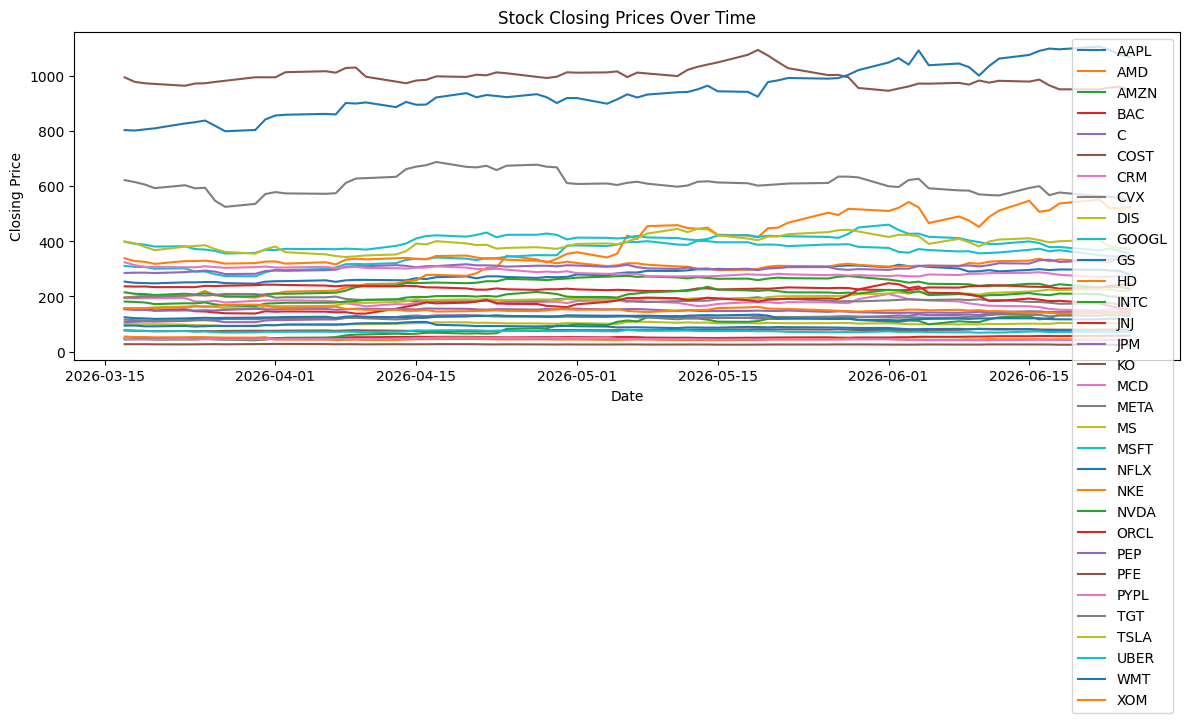

In [ ]:
# Closing Price Trend
plt.figure(figsize=(12,6))

for ticker in market_df["company_ticker"].unique():

    subset = market_df[
        market_df["company_ticker"] == ticker
    ]

    plt.plot(
        subset["Date"],
        subset["Close"],
        label=ticker
    )

plt.title("Stock Closing Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()

plt.tight_layout()
plt.savefig("market_closing_prices.png", dpi=300, bbox_inches="tight")

plt.show()

Closing price trends provide an overview of long-term stock movement.

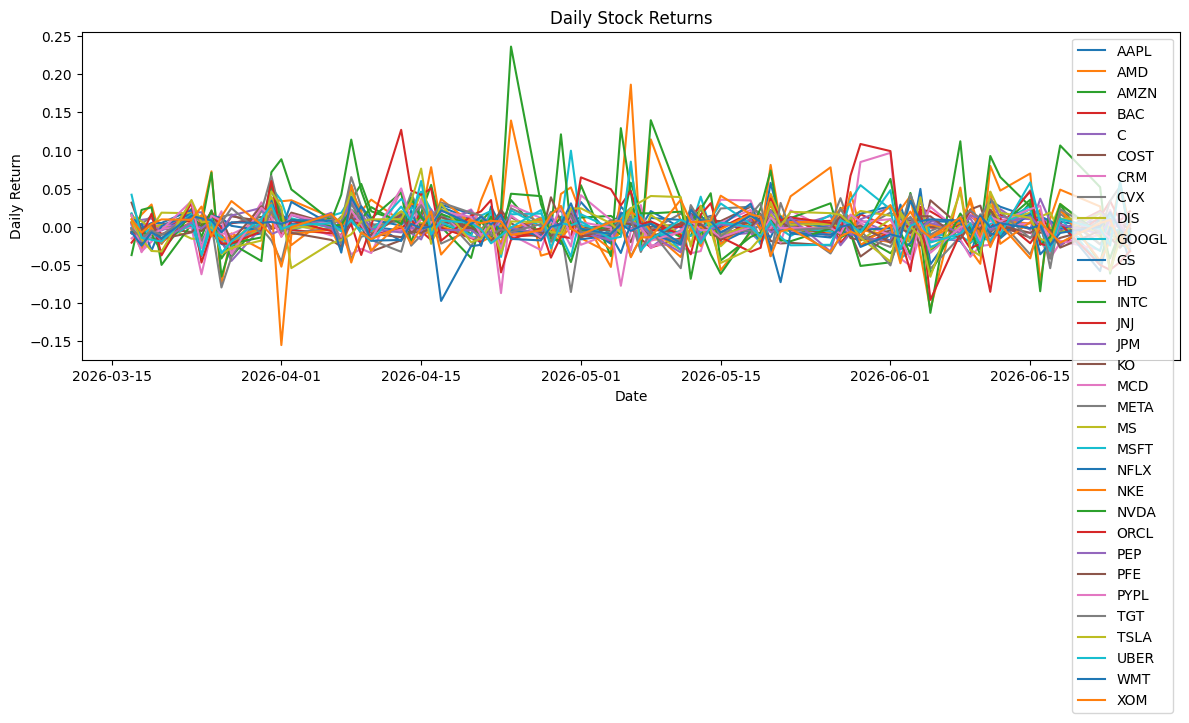

In [ ]:
# Daily Returns
plt.figure(figsize=(12,6))

for ticker in market_df["company_ticker"].unique():

    subset = market_df[
        market_df["company_ticker"] == ticker
    ]

    plt.plot(
        subset["Date"],
        subset["daily_return"],
        label=ticker
    )

plt.title("Daily Stock Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.legend()

plt.tight_layout()
plt.savefig("market_daily_returns.png", dpi=300, bbox_inches="tight")

plt.show()

Daily return analysis captures short-term market fluctuations following news events.

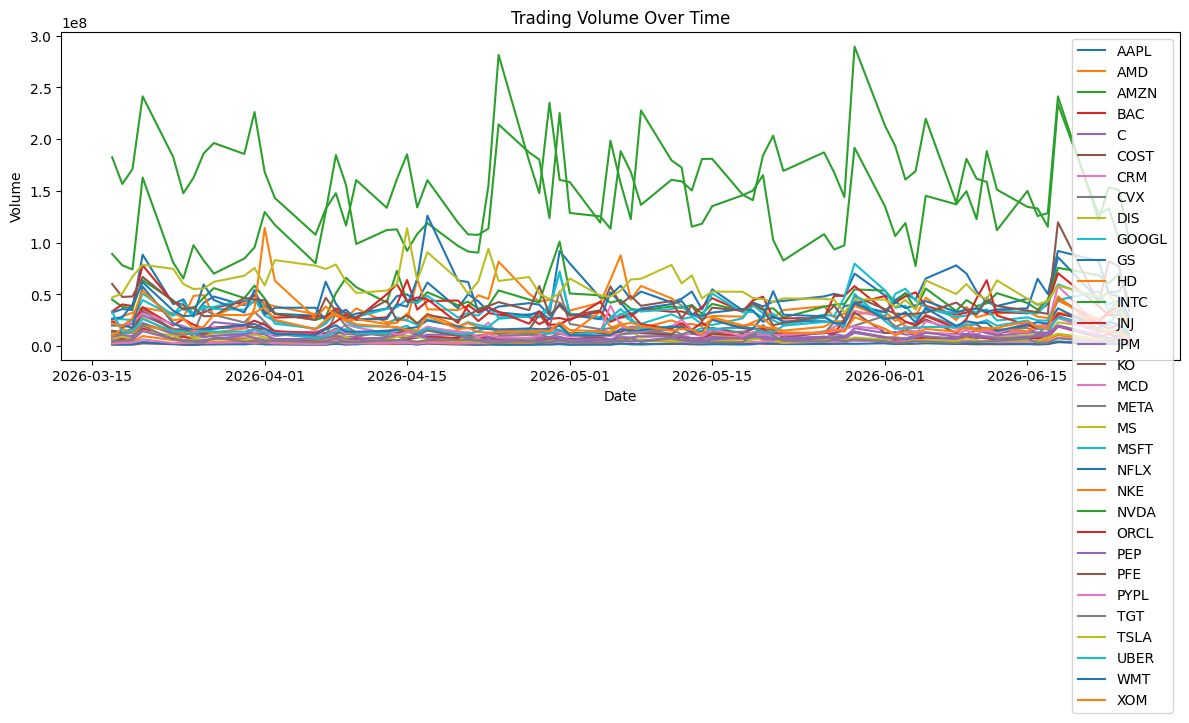

In [ ]:
# Trading Volume
plt.figure(figsize=(12,6))

for ticker in market_df["company_ticker"].unique():

    subset = market_df[
        market_df["company_ticker"] == ticker
    ]

    plt.plot(
        subset["Date"],
        subset["Volume"],
        label=ticker
    )

plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.legend()

plt.tight_layout()
plt.savefig("market_trading_volume.png", dpi=300, bbox_inches="tight")

plt.show()

Trading volume indicates changes in market activity and investor attention.

**Market Data Variables**

| Variable | Type | Role | Description |
|---|---|---|---|
| `Date` | Date | Linking Variable | Trading date |
| `company_ticker` | Categorical | Linking Variable | Company identifier |
| `Open` | Numeric | Feature | Opening stock price |
| `High` | Numeric | Feature | Highest daily price |
| `Low` | Numeric | Feature | Lowest daily price |
| `Close` | Numeric | Feature | Closing stock price |
| `Volume` | Numeric | Feature | Trading activity |
| `daily_return` | Numeric | Outcome | Daily percentage return |
| `volatility` | Numeric | Outcome | Market price fluctuation |

In [ ]:
# Market Data Quality Check
print("Missing Values")
display(market_df.isnull().sum())

Missing Values


,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
company_ticker,0
daily_return,0
volatility,0


In [ ]:
print(
    "Duplicate Rows:",
    market_df.duplicated().sum()
)

Duplicate Rows: 0


**Market Data Quality Assessment**

The market dataset was checked for missing values, duplicate records, and consistency of financial variables.

Daily returns and volatility measures were calculated during preprocessing. The final dataset contains complete time-series observations required for linking financial news with market outcomes.

---
**Dataset 3 - Synthetic Financial Misinformation Dataset**

Synthetic misinformation samples were generated later in the project using Large Language Model prompting strategies applied to authentic financial news articles.

These generated articles are not used for historical market reaction analysis because financial markets cannot respond to content created after the event.

Instead, synthetic data is used for:
- misinformation detection experiments
- robustness evaluation
- testing model generalisation against AI-generated content

The generation process and analysis are presented in the Unsupervised / Generative block.

---
## Section 2 — Causal Inference Block

**Causal Analysis Setup**
<details>
<summary><b>Causal Inference(Proposed)</b></summary>

### 4a. Causal Inference
- [x] Causal graph / DAG (DoWhy)
- [ ] Backdoor adjustment
- [ ] Instrumental variable
- [ ] Propensity score stratification
- [ ] Other: ___

*Justification:*

A Directed Acyclic Graph (DAG) will be used to conceptualize relationships between news characteristics, sentiment, market conditions, and observable market outcomes.

Potential confounding variables include:
- Overall market conditions
- Industry sector
- Firm size
- Earnings announcements
- Macroeconomic events

The DAG serves as a theoretical framework for identifying possible information transmission mechanisms and relevant confounding variables. Causal analysis will be used to estimate whether financial news sentiment is associated with subsequent market outcomes after controlling for observable confounders.

</details>

The causal analysis investigates whether sentiment extracted from financial news is associated with subsequent stock market returns.

- The treatment variable is the VADER sentiment score extracted from each financial news article.

- The outcome variable is the subsequent stock return (`future_return`).

- Potential confounders include company-specific characteristics, historical market trends, trading volume, and publication timing, as these factors may influence both the sentiment expressed in news articles and future market performance.

A causal Directed Acyclic Graph (DAG) is constructed to represent the assumed relationships between news sentiment, confounding factors, and market returns.

A backdoor adjustment strategy using the DoWhy framework is applied to estimate the association between financial news sentiment and future stock returns while controlling for the observed confounding variables identified in the DAG.


---
**Directed Acyclic Graph (DAG)**

A Directed Acyclic Graph (DAG) was constructed to formalize assumptions regarding the relationships between financial news characteristics, investor behaviour, and stock market outcomes.

The DAG provides the theoretical foundation for identifying confounding variables and selecting an appropriate adjustment strategy for causal estimation.

In [ ]:
# Create DAG
G = nx.DiGraph()

edges = [

    ("News Content", "VADER Sentiment"),
    ("News Content", "FinBERT Sentiment"),
    ("News Content", "Readability"),

    ("VADER Sentiment", "Investor Reaction"),
    ("FinBERT Sentiment", "Investor Reaction"),

    ("Readability", "Investor Reaction"),

    ("Investor Reaction", "Stock Return"),
    ("Investor Reaction", "Trading Volume"),
    ("Investor Reaction", "Volatility"),

    ("Market Conditions", "Stock Return"),
    ("Market Conditions", "Trading Volume"),
    ("Market Conditions", "Volatility"),

    ("Company", "News Content"),
    ("Company", "Stock Return")
]

G.add_edges_from(edges)

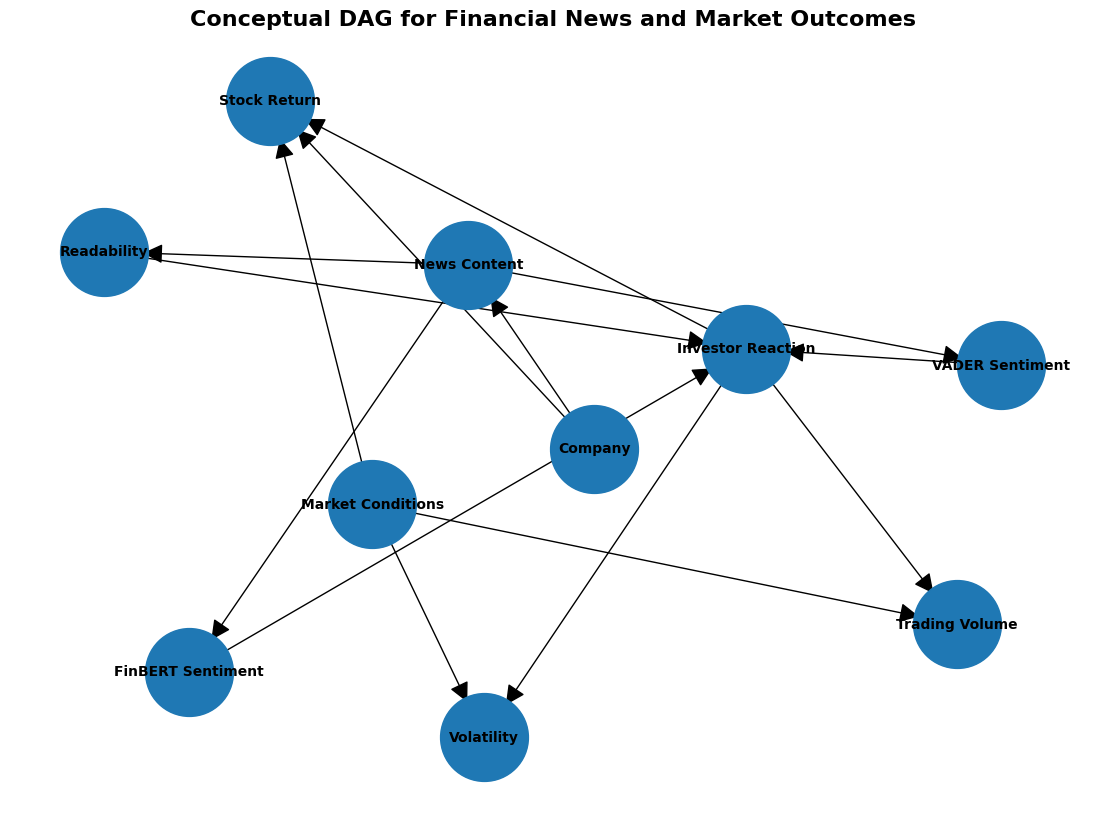

In [ ]:
# Plot DAG
plt.figure(figsize=(14,10))

pos = nx.spring_layout(
    G,
    seed=42,
    k=1.8
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=4000,
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowsize=30,
    edge_color="black",
    min_source_margin=28,
    min_target_margin=28,
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_color="black",
    font_weight="bold"
)

plt.title(
    "Conceptual DAG for Financial News and Market Outcomes",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")
plt.show()

The DAG illustrates how financial news characteristics influence investor reactions and subsequent market outcomes.

- News content affects sentiment and readability.
- Investor reaction mediates the relationship between news characteristics and market behaviour.
- Market conditions and company-specific factors influence stock performance independently of news sentiment.

These assumptions motivate adjustment for company and market-related confounders during causal estimation.

---
**DoWhy Causal Model**

**Preparing the Causal Dataset**

The dataset was further processed before causal estimation.

The following preprocessing steps were applied:

- observations sorted chronologically
- market trend calculated using a rolling five-day average return
- incomplete observations removed
- publication dates converted into numerical format for modelling

In [ ]:
# Load final dataset prepared for causal analysis
causal_df = pd.read_csv(
    f"{project_path}/data/processed/market_prediction_dataset.csv"
)

print("Causal Dataset Shape:")
print(causal_df.shape)

Causal Dataset Shape:
(179, 24)


In [ ]:
# Dataset Inspection
causal_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179 entries, 0 to 178
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   company_ticker     179 non-null    object 
 1   publication_date   179 non-null    object 
 2   title              179 non-null    object 
 3   article_text       179 non-null    object 
 4   source             179 non-null    object 
 5   word_count         179 non-null    int64  
 6   company            179 non-null    object 
 7   vader_sentiment    179 non-null    float64
 8   finbert_sentiment  179 non-null    object 
 9   finbert_score      179 non-null    int64  
 10  readability        179 non-null    float64
 11  sentence_length    179 non-null    float64
 12  Date               179 non-null    object 
 13  Open               179 non-null    float64
 14  High               179 non-null    float64
 15  Low                179 non-null    float64
 16  Close              179 non

In [ ]:
display(causal_df.head())

,company_ticker,publication_date,title,article_text,source,word_count,company,vader_sentiment,finbert_sentiment,finbert_score,...,High,Low,Close,Volume,daily_return,volatility,previous_return,previous_volume,future_return,future_volume
0,AAPL,2026-06-22,Memory's price surge threatens Apple's 'magic ...,Wall Street Journal technology reporter Rolfe ...,Yahoo Finance Video,28,Apple,0.0000,negative,-1,...,302.420013,296.76001,297.01001,44879900.0,-0.003356,0.013801,0.006961,85962200.0,-0.009124,52010900.0
1,AAPL,2026-06-22,What Dell Stock's AI Order Book Revealed Befor...,"Before the stock more than tripled, the compan...",Trefis,25,Apple,-0.5023,neutral,0,...,302.420013,296.76001,297.01001,44879900.0,-0.003356,0.013801,0.006961,85962200.0,-0.009124,52010900.0
2,AAPL,2026-06-22,Tim Cook Says 'Pretty Good' Workers Master The...,Apple Inc. CEO Tim Cook says the difference be...,Benzinga,90,Apple,0.9625,neutral,0,...,302.420013,296.76001,297.01001,44879900.0,-0.003356,0.013801,0.006961,85962200.0,-0.009124,52010900.0
3,AAPL,2026-06-22,"Stocks to Watch Recap: SpaceX, Alphabet, AbbVi...",↗️ AbbVie (ABBV): The pharmaceutical company a...,The Wall Street Journal,32,Apple,0.6486,positive,1,...,302.420013,296.76001,297.01001,44879900.0,-0.003356,0.013801,0.006961,85962200.0,-0.009124,52010900.0
4,AAPL,2026-06-22,The Best Warren Buffett Dividend Stocks,The best Warren Buffett dividend stocks are ex...,Kiplinger,24,Apple,0.8807,neutral,0,...,302.420013,296.76001,297.01001,44879900.0,-0.003356,0.013801,0.006961,85962200.0,-0.009124,52010900.0


In [ ]:
display(causal_df.describe(include="all"))

,company_ticker,publication_date,title,article_text,source,word_count,company,vader_sentiment,finbert_sentiment,finbert_score,...,High,Low,Close,Volume,daily_return,volatility,previous_return,previous_volume,future_return,future_volume
count,179,179,179,179,179,179.000000,179,179.000000,179,179.000000,...,179.000000,179.000000,179.000000,1.790000e+02,179.000000,179.000000,179.000000,1.790000e+02,179.000000,1.790000e+02
unique,32,5,179,174,38,NaN,32,NaN,3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,JPM,2026-06-22,Memory's price surge threatens Apple's 'magic ...,A number of stocks fell in the afternoon sessi...,Insider Monkey,NaN,JPMorgan Chase,NaN,negative,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,10,108,1,6,25,NaN,10,NaN,63,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,47.910615,NaN,0.345939,NaN,-0.027933,...,274.070001,267.037572,270.506700,2.701216e+07,-0.004315,0.021257,-0.002116,3.858665e+07,-0.005188,2.719355e+07
std,NaN,NaN,NaN,NaN,NaN,25.366147,NaN,0.412320,NaN,0.824009,...,266.703856,259.527207,264.347984,2.911780e+07,0.022651,0.010870,0.024188,3.500188e+07,0.019168,2.822520e+07
min,NaN,NaN,NaN,NaN,NaN,20.000000,NaN,-0.978800,NaN,-1.000000,...,25.240000,24.690001,24.719999,1.894400e+06,-0.061445,0.011018,-0.058155,1.894400e+06,-0.061445,1.931300e+06
25%,NaN,NaN,NaN,NaN,NaN,26.000000,NaN,0.146850,NaN,-1.000000,...,118.400002,116.949997,117.180000,8.518300e+06,-0.010783,0.013861,-0.020819,1.540550e+07,-0.015116,1.023580e+07
50%,NaN,NaN,NaN,NaN,NaN,48.000000,NaN,0.381800,NaN,0.000000,...,176.399994,174.399994,175.070007,1.739630e+07,-0.000823,0.017285,-0.005008,2.721520e+07,-0.004668,1.445740e+07
75%,NaN,NaN,NaN,NaN,NaN,66.000000,NaN,0.670500,NaN,1.000000,...,332.769989,326.750000,331.480011,3.633075e+07,0.009610,0.022061,0.010295,4.794145e+07,0.008025,3.692640e+07


The dataset combines textual features extracted from financial news with historical market indicators. These variables provide the basis for estimating the relationship between news sentiment and subsequent market performance.

In [ ]:
# Create Market Trend
causal_df = causal_df.sort_values(["company_ticker", "publication_date"])

causal_df["market_trend"] = (
    causal_df.groupby("company_ticker")["daily_return"]
    .transform(lambda x: x.rolling(5, min_periods=1).mean())
)

In [ ]:
# Remove Missing Values
causal_df = causal_df.dropna(
    subset=[
        "market_trend",
        "vader_sentiment",
        "future_return"
    ]
)

causal_df.shape

(179, 25)

In [ ]:
print(causal_df.columns.tolist())

['company_ticker', 'publication_date', 'title', 'article_text', 'source', 'word_count', 'company', 'vader_sentiment', 'finbert_sentiment', 'finbert_score', 'readability', 'sentence_length', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'daily_return', 'volatility', 'previous_return', 'previous_volume', 'future_return', 'future_volume', 'market_trend']


The resulting dataset contains the treatment, outcome and adjustment variables required for causal estimation using DoWhy.

In [ ]:
# Dowhy Model
graph = """
digraph {

    company_ticker -> vader_sentiment;
    company_ticker -> future_return;

    market_trend -> future_return;
    Volume -> future_return;
    publication_date -> future_return;

    vader_sentiment -> future_return;
}
"""

In [ ]:
model = CausalModel(
    data=causal_df,
    treatment="vader_sentiment",
    outcome="future_return",
    graph=graph
)

print("Model created")

ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...


Model created


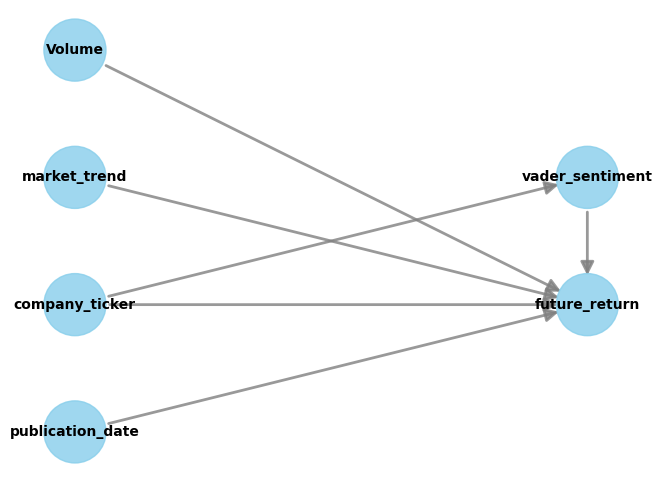

In [ ]:
# Display Model
print(model)

model.view_model()

DoWhy causal graph shows how future_return is influenced by several key factors — vader_sentiment, Volume, publication_date, company_ticker, and market_trend.

In [ ]:
# Identification of the Causal Effect
identified_estimand = model.identify_effect()

print(type(identified_estimand))
print(identified_estimand)

<class 'dowhy.causal_identifier.identified_estimand.IdentifiedEstimand'>
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                         
─────────────────(E[future_return|company_ticker])
d[vaderₛₑₙₜᵢₘₑₙₜ]                                 
Estimand assumption 1, Unconfoundedness: If U→{vader_sentiment} and U→future_return then P(future_return|vader_sentiment,company_ticker,U) = P(future_return|vader_sentiment,company_ticker)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
        d                                         
─────────────────(E[future_return|company_ticker])
d[vaderₛₑₙₜᵢₘₑₙₜ]                                 
Estimand assumption 1, Unconfoundedness: If U→{vader_sentiment} and U→future_return then P(future_return|vader_sentim

The model identifies the causal effect of VADER sentiment on future returns via backdoor adjustment through company_ticker, yielding an estimand of 𝑑/𝑑[vader_sentiment] E[future_return | company_ticker].

In [ ]:
# Effect Estimation
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)

print(estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                         
─────────────────(E[future_return|company_ticker])
d[vaderₛₑₙₜᵢₘₑₙₜ]                                 
Estimand assumption 1, Unconfoundedness: If U→{vader_sentiment} and U→future_return then P(future_return|vader_sentiment,company_ticker,U) = P(future_return|vader_sentiment,company_ticker)

## Realized estimand
b: future_return~vader_sentiment+company_ticker+vader_sentiment*market_trend+vader_sentiment*Volume+vader_sentiment*publication_date
Target units: 

## Estimate
Mean value: -0.0002650272739836892
### Conditional Estimates
__categorical__market_trend       __categorical__Volume      publication_date
(-0.062400000000000004, -0.0139]  (1894399.999, 7582200.0]   2026-06-17         -0.023683
                                                             2026-06-22          0.007562

In [ ]:
print("Estimated causal effect:", estimate.value)

Estimated causal effect: -0.0002650272739836892


The estimated causal effect is -0.000265, suggesting a small negative association between financial news sentiment and subsequent stock returns after adjusting for the observed confounding variables.

In [ ]:
# Refutation Analysis
refute_results = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="random_common_cause"
)

print(refute_results)

Refute: Add a random common cause
Estimated effect:-0.00026502697939324686
New effect:-0.0002629677368110672
p value:0.98



The random common cause refutation was performed to assess the robustness of the estimated causal effect. After introducing an artificial confounding variable, the estimated effect changed only marginally (from −0.000265 to −0.000263), with a p-value of 0.98. This indicates that the causal estimate is highly stable and not sensitive to the inclusion of random noise, providing additional confidence in the robustness of the backdoor adjustment strategy.

> The experimental results suggest that financial news features provide complementary information beyond historical market variables, although historical market indicators remain the strongest predictors of short-term return direction. Machine learning models successfully capture relationships between textual characteristics and market outcomes, while the causal analysis suggests that news sentiment may influence future stock returns after accounting for observed confounding variables. Together, these analyses provide complementary predictive and causal perspectives on the role of financial information in market behaviour.

---
## Section 3 — Supervised Learning Block


**Supervised Learning Setup**
<details>
<summary><b>Supervised Learning(Proposed)</b></summary>

### 4b. Supervised Learning
- [ ] Linear / Ridge / Lasso regression
- [x] Logistic regression
- [ ] k-Nearest Neighbors
- [x] Support Vector Machine
- [x] Decision Tree / Random Forest
- [x] Neural network (regression or classification)
- [x] Other: Transformer-Based Model (FinBERT)

*Justification:*

Multiple machine learning architectures will be compared to evaluate their ability to detect AI-generated financial misinformation.

- Logistic Regression will serve as an interpretable baseline using TF-IDF features.
- Random Forest will capture nonlinear interactions.
- Support Vector Machines provide strong performance in high-dimensional text classification.
- Feedforward Neural Networks will model complex feature interactions.
- FinBERT, a transformer model specialized for financial text, will serve as the advanced benchmark.

Hyperparameter optimization will be performed using Grid Search and Random Search combined with Stratified Cross-Validation.
</details>

The supervised learning component investigates whether machine learning models can accurately distinguish AI-generated financial misinformation from authentic financial news.

The detection task is formulated as a binary classification problem:

0 → Real financial article  
1 → AI-generated financial article

Models are evaluated progressively:

1. Classical machine learning using TF-IDF
2. Neural network using TF-IDF features
3. Financial-domain transformer model (FinBERT)

**Hyperparameter Tuning**

Randomized search with cross-validation was applied to improve baseline models.

The optimisation criterion was F1-score because the task requires balancing correct detection of AI-generated content while avoiding false accusations against real articles.

This allows comparison between traditional and advanced NLP approaches.

In [ ]:
# Load feature engineered dataset
df = pd.read_csv(
    f"{project_path}/data/processed/features_dataset.csv"
)

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (400, 16)


,article,label,source_type,prompt_type,positive_score,negative_score,neutral_score,vader_compound,finbert_sentiment,flesch_score,gunning_fog,word_count,sentence_count,avg_sentence_length,capital_ratio,punctuation_count
0,McDonald's is bringing back its Fried Apple Pi...,0,real,original,0.112,0.020,0.868,0.8271,positive,71.695862,9.109360,87.0,9.0,9.666667,0.048780,16.0
1,We recently published Jim Cramer Discussed Exp...,0,real,original,0.037,0.055,0.908,-0.2732,negative,61.532500,11.325926,56.0,4.0,14.000000,0.112045,17.0
2,(Bloomberg) -- For the first time in four year...,0,real,original,0.111,0.095,0.795,0.1280,positive,48.638333,15.666667,81.0,3.0,27.000000,0.106212,10.0
3,Goldman Sachs now sees a smaller chance of a r...,0,real,original,0.202,0.234,0.565,-0.3612,negative,78.087039,9.208772,57.0,6.0,9.500000,0.023333,11.0
4,Stock futures were tumbling on Tuesday as inve...,0,real,original,0.061,0.000,0.939,0.4767,negative,34.868912,17.145578,49.0,6.0,8.166667,0.034783,11.0


In [ ]:
print("Label Distribution")

display(df["label"].value_counts())

display(df["label"].value_counts(normalize=True) * 100)

Label Distribution


,count
label,
1,300
0,100


,proportion
label,
1,75.0
0,25.0


**Baseline Misinformation Detection Models**

This section evaluates baseline machine learning models for detecting
AI-generated financial misinformation.

Models:

- Logistic Regression
- Random Forest
- Support Vector Machine (SVM)

Features:

- TF-IDF representations of article text

Evaluation Metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

In [ ]:
# Prepare data for model development
X = df["article"]
y = df["label"]

In [ ]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(320,)
(80,)


**TF-IDF Feature Extraction**

TF-IDF was selected as a baseline because it provides an interpretable
representation of important words while remaining computationally efficient.

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(320, 4374)


In [ ]:
# Evaluation Funtion
def evaluate_model(
    model,
    X_test,
    y_test
):

    predictions = model.predict(
        X_test
    )

    probabilities = model.predict_proba(
        X_test
    )[:,1]

    metrics = {
        "Accuracy":
        accuracy_score(
            y_test,
            predictions
        ),

        "Precision":
        precision_score(
            y_test,
            predictions
        ),

        "Recall":
        recall_score(
            y_test,
            predictions
        ),

        "F1":
        f1_score(
            y_test,
            predictions
        ),

        "ROC_AUC":
        roc_auc_score(
            y_test,
            probabilities
        )
    }

    return (
        metrics,
        predictions,
        probabilities
    )

---
**Logistic Regression**

In [ ]:
logistic = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
logistic_metrics, logistic_pred, logistic_prob = evaluate_model(
    logistic,
    X_test_tfidf,
    y_test
)

pd.DataFrame(
    [logistic_metrics]
)

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.8,0.789474,1.0,0.882353,0.85


In [ ]:
# Classification report
print(
    classification_report(
        y_test,
        logistic_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.20      0.33        20
           1       0.79      1.00      0.88        60

    accuracy                           0.80        80
   macro avg       0.89      0.60      0.61        80
weighted avg       0.84      0.80      0.75        80



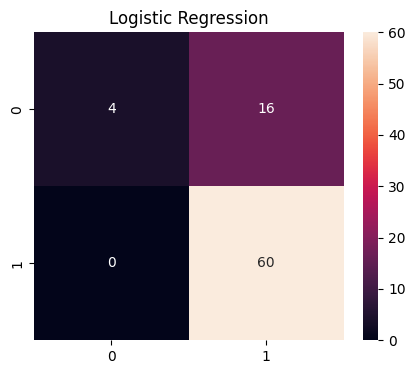

In [ ]:
# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(
        y_test,
        logistic_pred
    ),
    annot=True,
    fmt="d"
)

plt.title(
    "Logistic Regression"
)

plt.show()

Logistic Regression prioritized capturing all AI‑generated content, achieving perfect recall. The model prioritised sensitivity toward AI-generated content, resulting in higher recall but more false positives.

---
**Random Forest**

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train_tfidf,
    y_train
)

RandomForestClassifier(random_state=42)

In [ ]:
rf_metrics, rf_pred, rf_prob = evaluate_model(
    rf,
    X_test_tfidf,
    y_test
)

pd.DataFrame(
    [rf_metrics]
)

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.825,0.96,0.8,0.872727,0.910833


In [ ]:
# Classification report
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.60      0.90      0.72        20
           1       0.96      0.80      0.87        60

    accuracy                           0.82        80
   macro avg       0.78      0.85      0.80        80
weighted avg       0.87      0.82      0.83        80



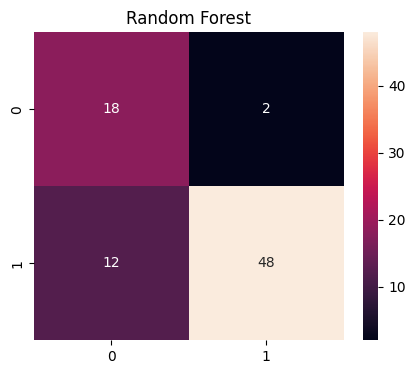

In [ ]:
# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(
        y_test,
        rf_pred
    ),
    annot=True,
    fmt="d"
)

plt.title(
    "Random Forest"
)

plt.show()

The Random Forest classifier behaved conservatively, prioritizing precision over recall. It reliably avoided mislabeling human‑written articles as AI‑generated but failed to capture all AI‑generated content.

In [ ]:
# Cross-Validation
cv = cross_val_score(
    rf,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring="f1"
)

print(
    "Random Forest 5-Fold CV F1:",
    cv.mean(),
    "+/-",
    cv.std()
)

Random Forest 5-Fold CV F1: 0.8685530065159686 +/- 0.013196187888291987


5-fold cross-validation (**F1 = 0.869 ± 0.013**) shows stable performance across different data splits.

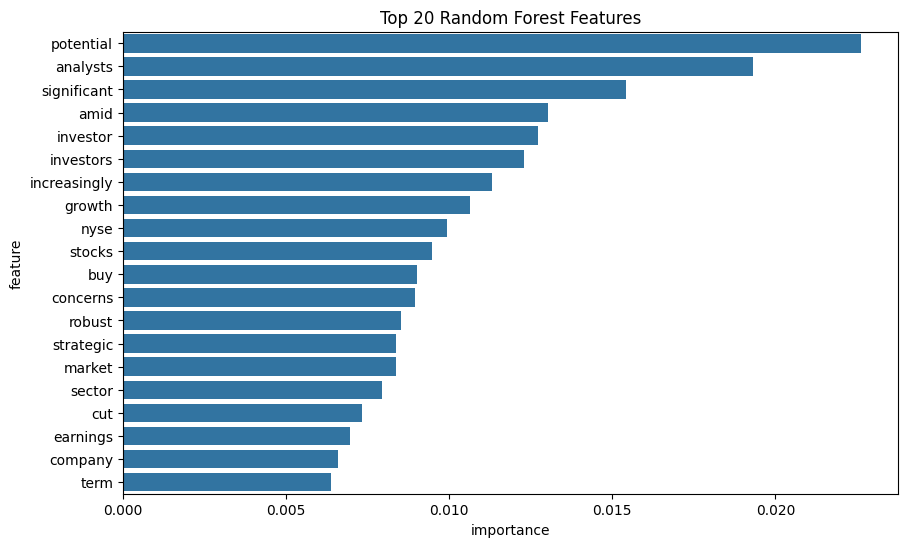

In [ ]:
# Feature Importance
importance = pd.DataFrame({
    "feature": tfidf.get_feature_names_out(),
    "importance": rf.feature_importances_
})

top20 = importance.sort_values(
    "importance",
    ascending=False
).head(20)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top20,
    x="importance",
    y="feature"
)

plt.title(
    "Top 20 Random Forest Features"
)

plt.show()

The feature importance analysis shows that certain terms contributed more strongly to classification decisions. These features represent linguistic patterns learned from the training data rather than direct indicators of misinformation.

In [ ]:
# Random Forest tuning
rf_params = {
    "n_estimators":[100,200,300],
    "max_depth":[None,10,20],
    "min_samples_split":[2,5,10]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=42
    ),
    rf_params,
    n_iter=5,
    cv=3,
    scoring="f1",
    random_state=42
)

rf_search.fit(
    X_train_tfidf,
    y_train
)

best_rf = rf_search.best_estimator_

best_rf

RandomForestClassifier(max_depth=20, min_samples_split=5, random_state=42)

In [ ]:
# Evaluate tuned RF
tuned_rf_metrics, tuned_rf_pred, tuned_rf_prob = evaluate_model(
    best_rf,
    X_test_tfidf,
    y_test
)

pd.DataFrame(
    [tuned_rf_metrics]
)

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.875,0.962963,0.866667,0.912281,0.938333


Hyperparameter tuning improved Random Forest performance compared with the baseline model.

The model achieved the highest precision (**0.963**), indicating reliable detection of AI-generated articles with fewer false positives.

Selected configuration:

`RandomForestClassifier(max_depth=20, min_samples_split=5)`

The tuned Random Forest was selected as the strongest classical model for robustness evaluation.

---
**SVM**

In [ ]:
svm = SVC(
    kernel="linear",
    probability=True,
    random_state=42
)

svm.fit(
    X_train_tfidf,
    y_train
)

SVC(kernel='linear', probability=True, random_state=42)

In [ ]:
svm_metrics, svm_pred, svm_prob = evaluate_model(
    svm,
    X_test_tfidf,
    y_test
)

pd.DataFrame(
    [svm_metrics]
)

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.825,0.848485,0.933333,0.888889,0.878333


In [ ]:
# Classification report
print(
    classification_report(
        y_test,
        svm_pred
    )
)

              precision    recall  f1-score   support

           0       0.71      0.50      0.59        20
           1       0.85      0.93      0.89        60

    accuracy                           0.82        80
   macro avg       0.78      0.72      0.74        80
weighted avg       0.81      0.82      0.81        80



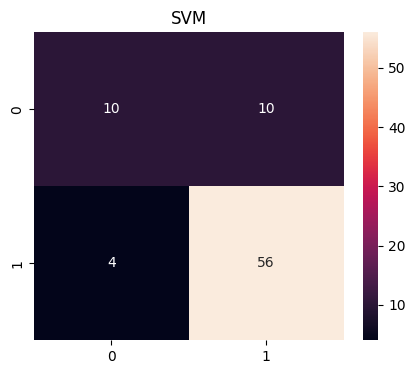

In [ ]:
# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(
        y_test,
        svm_pred
    ),
    annot=True,
    fmt="d"
)

plt.title(
    "SVM"
)

plt.show()

SVM achieved high recall and balanced performance, correctly identifying most AI‑generated articles with moderate false positives.

In [ ]:
# Cross-Validation
cv = cross_val_score(
    svm,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring="f1"
)

print(
    "SVM 5-Fold CV F1:",
    cv.mean(),
    "+/-",
    cv.std()
)

SVM 5-Fold CV F1: 0.8731295156574511 +/- 0.02320598830348247


The 5-fold cross-validation result (**F1 = 0.873 ± 0.023**) indicates consistent performance across different data splits.

In [ ]:
# SVM tuning
svm_params = {
    "C":[0.1,1,10],
    "kernel":["linear","rbf"]
}

svm_search = RandomizedSearchCV(
    SVC(
        probability=True,
        random_state=42
    ),
    svm_params,
    n_iter=4,
    cv=3,
    scoring="f1"
)

svm_search.fit(
    X_train_tfidf,
    y_train
)

best_svm = svm_search.best_estimator_

best_svm

SVC(C=1, kernel='linear', probability=True, random_state=42)

In [ ]:
# Evaluate tuned SVM
tuned_svm_metrics, tuned_svm_pred, tuned_svm_prob  = evaluate_model(
    best_svm,
    X_test_tfidf,
    y_test
)

pd.DataFrame(
    [tuned_svm_metrics]
)

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.825,0.848485,0.933333,0.888889,0.878333


Hyperparameter tuning produced performance comparable to the baseline SVM, indicating that the original configuration was already well suited to the dataset.

SVM maintained the highest recall (**0.933**), successfully detecting most AI-generated articles.  

Selected configuration:

`SVC(C=1, kernel='linear')`

The results show that linear decision boundaries are effective for TF-IDF based financial text classification.

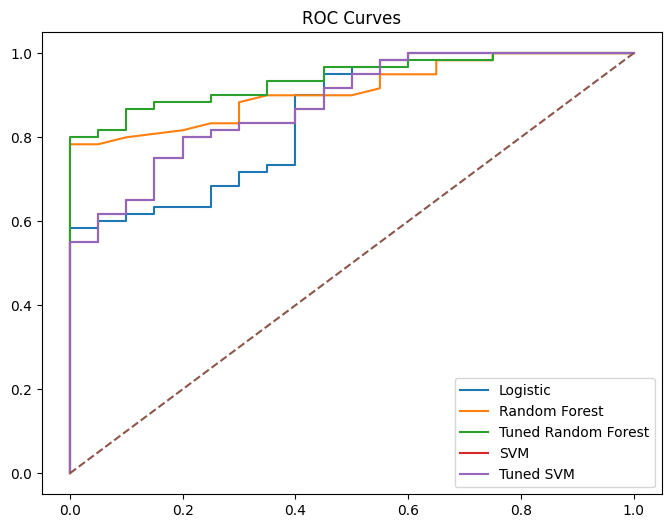

In [ ]:
# ROC Curves
plt.figure(figsize=(8,6))

for name, probs in [
    ("Logistic", logistic_prob),
    ("Random Forest", rf_prob),
    ("Tuned Random Forest", tuned_rf_prob),
    ("SVM", svm_prob),
    ("Tuned SVM", tuned_svm_prob)
]:

    fpr, tpr, _ = roc_curve(
        y_test,
        probs
    )

    plt.plot(
        fpr,
        tpr,
        label=name
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.legend()

plt.title("ROC Curves")

plt.show()

All models performed well; SVM and Random Forest showed slightly stronger ROC curves than Logistic Regression.

In [ ]:
# Baseline models comparision
baseline_comparison = pd.DataFrame(
    [
        {
            "Model":
            "Logistic Regression",
            **logistic_metrics
        },

        {
            "Model":
            "Random Forest",
            **rf_metrics
        },

        {
            "Model":
            "Tuned Random Forest",
            **tuned_rf_metrics
        },

        {
            "Model":
            "SVM",
            **svm_metrics
        },

        {
            "Model":
            "Tuned SVM",
            **tuned_svm_metrics
        }
    ]
)

baseline_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.800,0.789474,1.000000,0.882353,0.850000
1,Random Forest,0.825,0.960000,0.800000,0.872727,0.910833
2,Tuned Random Forest,0.875,0.962963,0.866667,0.912281,0.938333
3,SVM,0.825,0.848485,0.933333,0.888889,0.878333
4,Tuned SVM,0.825,0.848485,0.933333,0.888889,0.878333


The comparison shows the impact of hyperparameter tuning on the classical machine learning models.

- **Tuned Random Forest** achieved the best overall performance, improving the F1-score from **0.873** to **0.912** and the ROC-AUC from **0.911** to **0.938**, demonstrating that parameter optimization substantially enhanced its detection capability.

- **SVM** maintained the same performance after tuning (F1 = **0.889**), indicating that the original configuration was already close to optimal for the TF-IDF feature space.

- **Logistic Regression** achieved perfect recall (**1.000**), successfully detecting all AI-generated articles, but produced more false positives than the other models.

Overall, hyperparameter tuning was most beneficial for **Random Forest**, which became the strongest classical machine learning model and was selected for the subsequent robustness evaluation.

---
**Advanced Detection Models**

To evaluate whether advanced NLP-based models can improve the detection of AI-generated financial misinformation, additional models were trained.

The following approaches were evaluated:

- Multi-Layer Perceptron (MLP) Neural Network
- Fine-tuned FinBERT Transformer Model

The neural network uses TF-IDF representations, while FinBERT uses contextual embeddings learned from financial text.

Evaluation Metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

---
**Multi-Layer Perceptron (MLP) Neural Network**

In [ ]:
# Scale TF-IDF Features
scaler = MaxAbsScaler()

X_train_scaled = scaler.fit_transform(
    X_train_tfidf
)

X_test_scaled = scaler.transform(
    X_test_tfidf
)

In [ ]:
# Train Neural Network
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    learning_rate="adaptive",
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

mlp.fit(
    X_train_scaled,
    y_train
)

MLPClassifier(early_stopping=True, hidden_layer_sizes=(256, 128),
              learning_rate='adaptive', max_iter=500, random_state=42)

In [ ]:
# Predictions
nn_pred = mlp.predict(
    X_test_scaled
)

nn_prob = mlp.predict_proba(
    X_test_scaled
)[:, 1]

In [ ]:
# Metrics
nn_metrics, nn_pred, nn_prob = evaluate_model(
    mlp,
    X_test_scaled,
    y_test
)

pd.DataFrame([nn_metrics])

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.8,0.814286,0.95,0.876923,0.835833


In [ ]:
# Classification report
print(
    classification_report(
        y_test,
        nn_pred
    )
)

              precision    recall  f1-score   support

           0       0.70      0.35      0.47        20
           1       0.81      0.95      0.88        60

    accuracy                           0.80        80
   macro avg       0.76      0.65      0.67        80
weighted avg       0.79      0.80      0.77        80



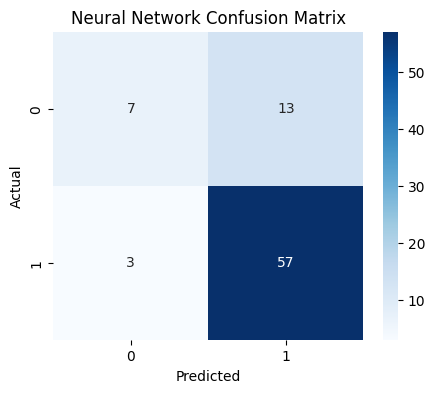

In [ ]:
# Confusion Matrix
plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(
        y_test,
        nn_pred
    ),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

The model achieved high recall (0.95), indicating strong detection capability for AI-generated articles.

However, performance remained comparable to traditional TF-IDF-based models, suggesting that a simple neural architecture provides limited improvement without richer text representations

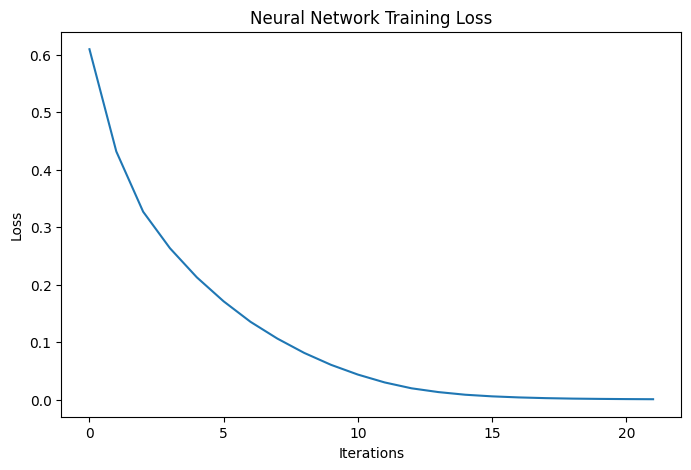

In [ ]:
# Training Curve
plt.figure(figsize=(8,5))
plt.plot(mlp.loss_curve_)
plt.title("Neural Network Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

Loss steadily decreased across iterations, confirming effective learning and convergence.

In [ ]:
# Neural Network tuning
nn_params = {
    "hidden_layer_sizes":[(100,),(150,),(100,50)],
    "learning_rate_init":[0.001,0.0005]
}

nn_search = RandomizedSearchCV(
    MLPClassifier(
        max_iter=500,
        random_state=42
    ),
    nn_params,
    n_iter=4,
    cv=3,
    scoring="f1",
    random_state=42
)

nn_search.fit(
    X_train_tfidf,
    y_train
)

best_nn = nn_search.best_estimator_

best_nn

MLPClassifier(hidden_layer_sizes=(150,), max_iter=500, random_state=42)

In [ ]:
tuned_nn_metrics, tuned_nn_pred, tuned_nn_prob = evaluate_model(
    best_nn,
    X_test_tfidf,
    y_test
)

pd.DataFrame(
    [tuned_nn_metrics]
)

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.7625,0.847458,0.833333,0.840336,0.836667


The model achieved balanced precision and recall, but did not outperform classical TF-IDF approaches.

Selected configuration:

`MLPClassifier(hidden_layer_sizes=(150,))`

This suggests that increased model complexity alone does not guarantee better performance when using sparse TF-IDF features.

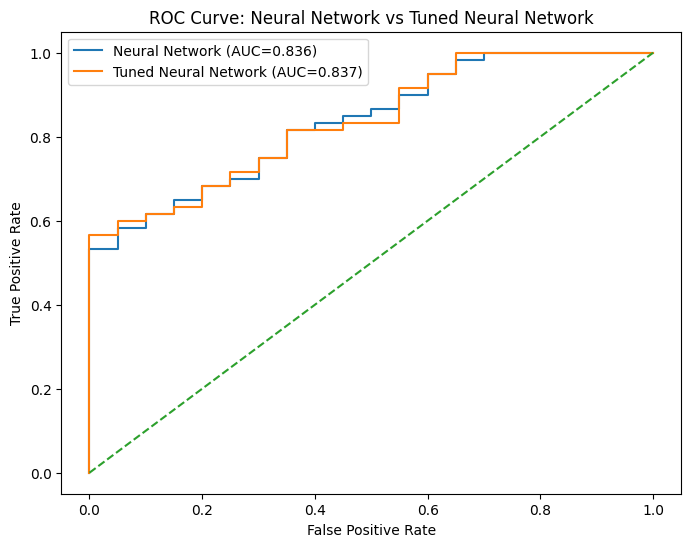

In [ ]:
# ROC Curves: Neural Network vs Tuned Neural Network
plt.figure(figsize=(8,6))

for name, probs in [
    ("Neural Network", nn_prob),
    ("Tuned Neural Network", tuned_nn_prob)
]:

    fpr, tpr, _ = roc_curve(
        y_test,
        probs
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={roc_auc:.3f})"
    )


# Random baseline
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Neural Network vs Tuned Neural Network")

plt.legend()

plt.show()

the tuned neural network slightly outperforms the baseline model, achieving a marginally higher AUC (0.837 vs. 0.836), indicating improved classification discrimination with nearly identical performance across false positive rates.

---
**FinBERT Fine-Tuning**

FinBERT was selected because financial misinformation detection requires understanding domain-specific language.

Unlike TF-IDF approaches, FinBERT captures contextual meaning and relationships between financial terms.

In [ ]:
# Prepare Dataset
finbert_df = df[
    [
        "article",
        "label"
    ]
].copy()

In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    finbert_df["article"],
    finbert_df["label"],
    test_size=0.2,
    random_state=42,
    stratify=finbert_df["label"]
)

In [ ]:
train_dataset = Dataset.from_dict(
    {
        "text": train_texts.tolist(),
        "label": train_labels.tolist()
    }
)

test_dataset = Dataset.from_dict(
    {
        "text": test_texts.tolist(),
        "label": test_labels.tolist()
    }
)

In [ ]:
# Load FinBERT
model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    ignore_mismatched_sizes=True
)

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
# Tokenize
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

In [ ]:
train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

In [ ]:
train_dataset.set_format(
    "torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

test_dataset.set_format(
    "torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(
        logits,
        axis=1
    )

    probabilities = torch.softmax(
        torch.tensor(logits),
        dim=1
    )[:,1].numpy()


    return {
        "accuracy":
        accuracy_score(
            labels,
            predictions
        ),

        "precision":
        precision_score(
            labels,
            predictions
        ),

        "recall":
        recall_score(
            labels,
            predictions
        ),

        "f1":
        f1_score(
            labels,
            predictions
        ),

        "roc_auc":
        roc_auc_score(
            labels,
            probabilities
        )
    }

In [ ]:
# Training
training_args = TrainingArguments(
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.354499,0.255034,0.925000,0.950000,0.950000,0.950000,0.967500
2,0.147563,0.174718,0.950000,0.966667,0.966667,0.966667,0.980833
3,0.059483,0.155176,0.950000,0.966667,0.966667,0.966667,0.980000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=120, training_loss=0.2132108060022195, metrics={'train_runtime': 132.3549, 'train_samples_per_second': 7.253, 'train_steps_per_second': 0.907, 'total_flos': 252586613145600.0, 'train_loss': 0.2132108060022195, 'epoch': 3.0})

In [ ]:
# Evaluate FinBERT
predictions = trainer.predict(
    test_dataset
)

probs = torch.softmax(
    torch.tensor(
        predictions.predictions
    ),
    dim=1
).numpy()

finbert_pred = np.argmax(
    probs,
    axis=1
)

finbert_prob = probs[:,1]

In [ ]:
finbert_metrics = {
    "Accuracy":
    accuracy_score(
        test_labels,
        finbert_pred
    ),

    "Precision":
    precision_score(
        test_labels,
        finbert_pred
    ),

    "Recall":
    recall_score(
        test_labels,
        finbert_pred
    ),

    "F1":
    f1_score(
        test_labels,
        finbert_pred
    ),

    "ROC_AUC":
    roc_auc_score(
        test_labels,
        finbert_prob
    )
}

pd.DataFrame(
    [finbert_metrics]
)

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.95,0.966667,0.966667,0.966667,0.980833


In [ ]:
# Classification report
print(
    classification_report(
        test_labels,
        finbert_pred
    )
)

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        20
           1       0.97      0.97      0.97        60

    accuracy                           0.95        80
   macro avg       0.93      0.93      0.93        80
weighted avg       0.95      0.95      0.95        80



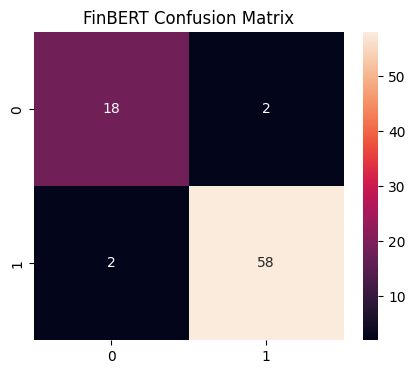

In [ ]:
# Confusion Matrix
plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(
        test_labels,
        finbert_pred
    ),
    annot=True,
    fmt="d"
)

plt.title(
    "FinBERT Confusion Matrix"
)

plt.show()

The fine-tuned FinBERT model achieved the highest performance among all evaluated models.

These results indicate that contextual financial language representations enable FinBERT to distinguish AI-generated and real financial articles more effectively than TF-IDF-based classical and neural network models. Consequently, FinBERT was selected as the final detection model.

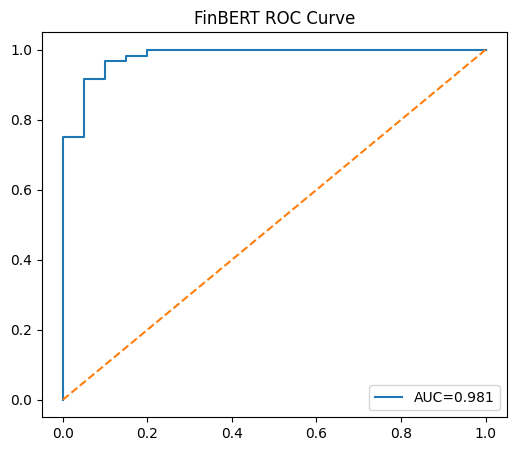

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(
    test_labels,
    finbert_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC={finbert_metrics['ROC_AUC']:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.legend()

plt.title("FinBERT ROC Curve")

plt.show()

The ROC curve achieved an **AUC of 0.981**, demonstrating excellent discrimination between AI-generated and authentic financial news. The high AUC indicates that FinBERT consistently separates the two classes across different decision thresholds, confirming its robustness for financial misinformation detection.

---
**Final Comparison Table**

The final comparison evaluates traditional machine learning, neural networks, and transformer-based approaches for detecting AI-generated financial misinformation.

In [ ]:
model_comparison = pd.DataFrame([
    {
        "Model":
        "Logistic Regression",
        **logistic_metrics
    },

    {
        "Model":
        "Random Forest",
        **rf_metrics
    },

    {
        "Model":
        "Tuned Random Forest",
        **tuned_rf_metrics
    },

    {
        "Model":
        "SVM",
        **svm_metrics
    },

    {
        "Model":
        "Tuned SVM",
        **tuned_svm_metrics
    },

    {
        "Model":
        "Neural Network",
        **nn_metrics
    },

    {
        "Model":
        "Tuned Neural Network",
        **tuned_nn_metrics
    },

    {
        "Model":
        "FinBERT",
        **finbert_metrics
    }
])

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.8000,0.789474,1.000000,0.882353,0.850000
1,Random Forest,0.8250,0.960000,0.800000,0.872727,0.910833
2,Tuned Random Forest,0.8750,0.962963,0.866667,0.912281,0.938333
3,SVM,0.8250,0.848485,0.933333,0.888889,0.878333
4,Tuned SVM,0.8250,0.848485,0.933333,0.888889,0.878333
5,Neural Network,0.8000,0.814286,0.950000,0.876923,0.835833
6,Tuned Neural Network,0.7625,0.847458,0.833333,0.840336,0.836667
7,FinBERT,0.9500,0.966667,0.966667,0.966667,0.980833


The final comparison demonstrates the effectiveness of both classical machine learning and transformer-based approaches for detecting AI-generated financial misinformation.

Among the classical models, **Tuned Random Forest** achieved the strongest performance (**F1 = 0.912**, **ROC-AUC = 0.938**), showing that hyperparameter optimisation substantially improved its detection capability. In contrast, hyperparameter tuning had little effect on SVM and did not improve the neural network.

Overall, **FinBERT** achieved the best performance across all evaluated models, with an **Accuracy of 95.0%**, **F1-score of 0.967**, and **ROC-AUC of 0.981**.

These results indicate that contextual financial language representations provide superior detection of AI-generated financial misinformation compared with TF-IDF-based machine learning models.

Therefore, **FinBERT was selected as the final detection model**, while the tuned Random Forest served as the strongest classical baseline for subsequent robustness evaluation.

In [ ]:
# Best Overall Model
best_model = model_comparison.loc[
    model_comparison["F1"].idxmax()
]

best_model

,7
Model,FinBERT
Accuracy,0.95
Precision,0.966667
Recall,0.966667
F1,0.966667
ROC_AUC,0.980833


---
**Robustness Evaluation**

The robustness experiment evaluated model performance across three synthetic misinformation styles:

- Bullish misinformation
- Bearish misinformation
- Neutral AI-generated rewrites

The objective is to test whether models remain reliable when misinformation becomes less obvious.

In [ ]:
# Load synthetic dataset for robustness evaluation
synthetic_df = pd.read_csv(
    f"{project_path}/data/processed/synthetic_financial_news.csv"
)

print("Synthetic dataset shape:", synthetic_df.shape)

Synthetic dataset shape: (400, 7)


In [ ]:
display(synthetic_df.head())

,generated_article,original_article,prompt_type,source_type,label,company,length
0,McDonald's is bringing back its Fried Apple Pi...,McDonald's is bringing back its Fried Apple Pi...,original,real,0,NaN,87
1,We recently published Jim Cramer Discussed Exp...,We recently published Jim Cramer Discussed Exp...,original,real,0,NaN,56
2,(Bloomberg) -- For the first time in four year...,(Bloomberg) -- For the first time in four year...,original,real,0,NaN,81
3,Goldman Sachs now sees a smaller chance of a r...,Goldman Sachs now sees a smaller chance of a r...,original,real,0,NaN,57
4,Stock futures were tumbling on Tuesday as inve...,Stock futures were tumbling on Tuesday as inve...,original,real,0,NaN,49


In [ ]:
print(synthetic_df["prompt_type"].value_counts())

prompt_type
original    100
bullish     100
bearish     100
neutral     100
Name: count, dtype: int64


In [ ]:
# Robustness Sets
bullish_df = synthetic_df[
    synthetic_df["prompt_type"] == "bullish"
].copy()

bearish_df = synthetic_df[
    synthetic_df["prompt_type"] == "bearish"
].copy()

neutral_df = synthetic_df[
    synthetic_df["prompt_type"] == "neutral"
].copy()

In [ ]:
# TF-IDF Transform
bullish_tfidf = tfidf.transform(
    bullish_df["generated_article"]
)

bearish_tfidf = tfidf.transform(
    bearish_df["generated_article"]
)

neutral_tfidf = tfidf.transform(
    neutral_df["generated_article"]
)

In [ ]:
# Robustness Evaluation
robustness_results = []

In [ ]:
datasets = {
    "Bullish":
    (bullish_tfidf, bullish_df["label"]),

    "Bearish":
    (bearish_tfidf, bearish_df["label"]),

    "Neutral":
    (neutral_tfidf, neutral_df["label"])
}

In [ ]:
models = {
    "Tuned Random Forest":
    best_rf,

    "Tuned SVM":
    best_svm,

    "Tuned Neural Network":
    best_nn
}

In [ ]:
for model_name, model in models.items():

    for dataset_name, (X_set, y_set) in datasets.items():

        metrics, predictions, probabilities = evaluate_model(
            model,
            X_set,
            y_set
        )

        metrics["Model"] = model_name
        metrics["Dataset"] = dataset_name

        robustness_results.append(metrics)

robustness_df = pd.DataFrame(
    robustness_results
)

robustness_df

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,Dataset
0,1.00,1.0,1.00,1.000000,NaN,Tuned Random Forest,Bullish
1,1.00,1.0,1.00,1.000000,NaN,Tuned Random Forest,Bearish
2,0.92,1.0,0.92,0.958333,NaN,Tuned Random Forest,Neutral
3,1.00,1.0,1.00,1.000000,NaN,Tuned SVM,Bullish
4,1.00,1.0,1.00,1.000000,NaN,Tuned SVM,Bearish
5,0.96,1.0,0.96,0.979592,NaN,Tuned SVM,Neutral
6,1.00,1.0,1.00,1.000000,NaN,Tuned Neural Network,Bullish
7,1.00,1.0,1.00,1.000000,NaN,Tuned Neural Network,Bearish
8,0.90,1.0,0.90,0.947368,NaN,Tuned Neural Network,Neutral


The evaluated models achieved very high performance on bullish and bearish synthetic misinformation samples.

However, performance decreased on neutral AI-generated rewrites. For example, Random Forest achieved an F1-score of 0.958 on neutral articles, compared with perfect performance on bullish and bearish variants.

This suggests that neutral rewrites more closely resemble authentic financial news and therefore represent a greater challenge for detection systems

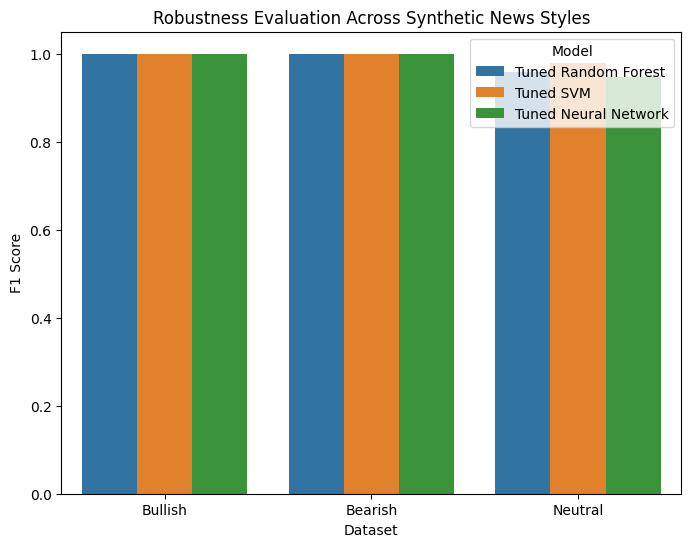

In [ ]:
# Robustness Visualization
plt.figure(figsize=(8,6))

sns.barplot(
    data=robustness_df,
    x="Dataset",
    y="F1",
    hue="Model"
)

plt.title("Robustness Evaluation Across Synthetic News Styles")

plt.ylabel("F1 Score")

plt.show()

**Prompt-Type Analysis**

Detection performance varied across prompt types.

- Bullish and bearish misinformation achieved near-perfect classification performance across all evaluated models.

- In contrast, neutral AI-generated rewrites consistently produced lower performance and accounted for most observed classification errors. For example, the Random Forest model achieved an F1-score of 0.958 on neutral rewrites, compared with perfect performance on bullish and bearish variants.

These findings suggest that detection systems are highly effective against overtly misleading narratives but face greater difficulty when AI-generated content preserves the original informational content while only modifying wording and structure.

In [ ]:
# Error Analysis
best_model = best_rf

neutral_pred = best_model.predict(
    neutral_tfidf
)

neutral_df["prediction"] = neutral_pred

false_negatives = neutral_df[
    neutral_df["prediction"] == 0
]

display(
    false_negatives.head(10)
)

,generated_article,original_article,prompt_type,source_type,label,company,length,prediction
114,"On Tuesday, stock futures experienced a sharp ...",Stock futures were tumbling on Tuesday as inve...,neutral,AI_generated,1,GOOGL,67,0
162,Chevron Corporation (NYSE: CVX) has been ident...,Chevron Corporation (NYSE:CVX) is one of the 1...,neutral,AI_generated,1,CVX,78,0
195,Shares of Block Inc (NYSE: SQ) surged 17% duri...,Block Inc (NYSE:SQ) shares rose 17% in early t...,neutral,AI_generated,1,SQ,49,0
198,In a recent episode of Motley Fool’s Hidden Ge...,A recent Motley Fool Hidden Gems Investing seg...,neutral,AI_generated,1,MCD,77,0
306,Leadership initially anchored its turnaround n...,Management once built its transformation story...,neutral,AI_generated,1,XOM,51,0
321,Amazon.com is set to use its upcoming Prime Da...,Amazon.com’s upcoming Prime Day will be a lit...,neutral,AI_generated,1,WMT,76,0
336,Holding a short interest equal to 1.21% of its...,With a short percentage of shares outstanding ...,neutral,AI_generated,1,HD,72,0
369,CGI has joined forces with Entersekt to improv...,CGI and Entersekt have partnered to enhance 3-...,neutral,AI_generated,1,PYPL,86,0


False negatives mainly appeared in neutral AI-generated rewrites.

These cases are difficult because the generated articles preserve realistic financial language and do not contain obvious misinformation patterns.

This suggests that future detection systems require stronger semantic understanding rather than relying only on surface-level text features.

---
## Section 4 — Unsupervised / Generative Block

**LLM-Based Synthetic Financial News Generation**
<details>
<summary><b>Unsupervised Learning(Proposed)</b></summary>

### 4c. Unsupervised Learning / Generative Models
- [ ] K-Means clustering
- [ ] Hierarchical clustering
- [ ] Variational autoencoder
- [ ] GAN
- [x] Other: Large Language Model (LLM)-Based Synthetic Financial News Generation

*Justification:*

A Large Language Model (e.g., GPT or Llama) will generate synthetic financial misinformation based on authentic financial news articles.

Multiple prompting strategies will be used to generate diverse misinformation examples and reduce overfitting to a single prompt style.

Generated articles will be used to:
- Simulate emerging misinformation scenarios.
- Expand the available dataset.
- Analyze risks associated with generative AI in financial markets.

Text embeddings, sentiment scores, readability measures, and linguistic features extracted from generated articles will be incorporated into downstream predictive models to ensure integration across methodological blocks.
</details>

A Large Language Model was used to generate synthetic financial misinformation from authentic financial news articles.

Three controlled prompting strategies were applied:

1. Bullish misinformation:
   - Exaggerated positive financial claims
   - Simulated over-optimistic investor narratives

2. Bearish misinformation:
   - Exaggerated negative claims
   - Simulated fear-driven market narratives

3. Neutral rewrite:
   - Preserved factual meaning
   - Modified wording and structure to simulate AI-generated text

The generated samples were used for robustness evaluation and to expand the training data for misinformation detection models.

---
**Generation Model Information**

The synthetic financial news articles were generated using **GPT-4.1-mini** with a **temperature of 0.8**.

A prompt-based controlled generation strategy was adopted instead of unrestricted text generation to ensure:

- Company consistency across generated articles
- Preservation of financial topic relevance
- Realistic financial misinformation patterns
- Reproducibility of the generation process

This controlled approach enabled the creation of diverse yet realistic synthetic financial news suitable for downstream detection and robustness evaluation.

In [ ]:
# Load generated dataset
synthetic_df = pd.read_csv(
    f"{project_path}/data/processed/synthetic_financial_news.csv"
)

synthetic_df.shape

(400, 7)

In [ ]:
synthetic_df.head()

,generated_article,original_article,prompt_type,source_type,label,company,length
0,McDonald's is bringing back its Fried Apple Pi...,McDonald's is bringing back its Fried Apple Pi...,original,real,0,NaN,87
1,We recently published Jim Cramer Discussed Exp...,We recently published Jim Cramer Discussed Exp...,original,real,0,NaN,56
2,(Bloomberg) -- For the first time in four year...,(Bloomberg) -- For the first time in four year...,original,real,0,NaN,81
3,Goldman Sachs now sees a smaller chance of a r...,Goldman Sachs now sees a smaller chance of a r...,original,real,0,NaN,57
4,Stock futures were tumbling on Tuesday as inve...,Stock futures were tumbling on Tuesday as inve...,original,real,0,NaN,49


In [ ]:
# Distribution Check
synthetic_df["prompt_type"].value_counts()

,count
prompt_type,
original,100
bullish,100
bearish,100
neutral,100


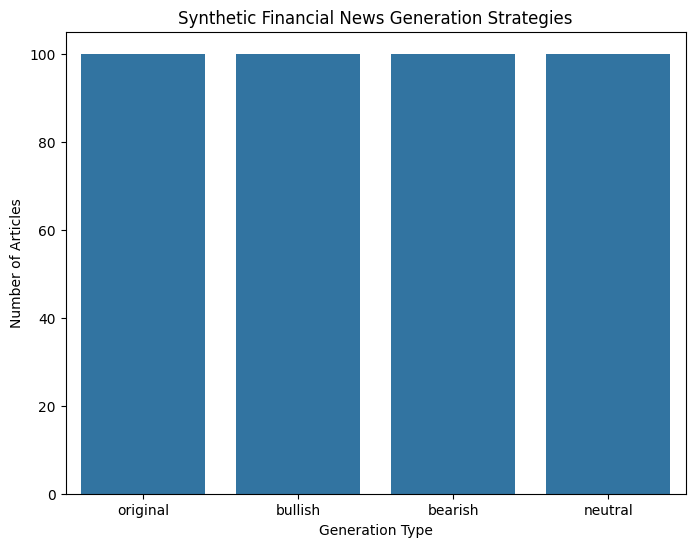

In [ ]:
# Plot Synthetic Types
plt.figure(figsize=(8,6))

sns.countplot(
    data=synthetic_df,
    x="prompt_type"
)

plt.title(
    "Synthetic Financial News Generation Strategies"
)

plt.xlabel("Generation Type")
plt.ylabel("Number of Articles")

plt.show()

---
**Feature Engineering**

Financial misinformation can differ from authentic news not only in factual
content but also in linguistic patterns.

Therefore, multiple feature categories are extracted:

- sentiment features capture emotional manipulation
- readability features capture writing complexity
- linguistic features capture writing style differences
- FinBERT representations capture financial semantic information

These features are combined to support downstream detection models.


In [ ]:
# Load features dataset
feature_df = pd.read_csv(
    f"{project_path}/data/processed/features_dataset.csv"
)

feature_df.head()

,article,label,source_type,prompt_type,positive_score,negative_score,neutral_score,vader_compound,finbert_sentiment,flesch_score,gunning_fog,word_count,sentence_count,avg_sentence_length,capital_ratio,punctuation_count
0,McDonald's is bringing back its Fried Apple Pi...,0,real,original,0.112,0.020,0.868,0.8271,positive,71.695862,9.109360,87.0,9.0,9.666667,0.048780,16.0
1,We recently published Jim Cramer Discussed Exp...,0,real,original,0.037,0.055,0.908,-0.2732,negative,61.532500,11.325926,56.0,4.0,14.000000,0.112045,17.0
2,(Bloomberg) -- For the first time in four year...,0,real,original,0.111,0.095,0.795,0.1280,positive,48.638333,15.666667,81.0,3.0,27.000000,0.106212,10.0
3,Goldman Sachs now sees a smaller chance of a r...,0,real,original,0.202,0.234,0.565,-0.3612,negative,78.087039,9.208772,57.0,6.0,9.500000,0.023333,11.0
4,Stock futures were tumbling on Tuesday as inve...,0,real,original,0.061,0.000,0.939,0.4767,negative,34.868912,17.145578,49.0,6.0,8.166667,0.034783,11.0


 **Synthetic Financial Misinformation Variables**

| Variable            | Type        | Role      | Description                                                          |
| ------------------- | ----------- | --------- | -------------------------------------------------------------------- |
| `generated_article` | Text        | Feature   | Final article used for model training (real or AI-generated)         |
| `original_article`  | Text        | Reference | Original financial news article before transformation                |
| `prompt_type`       | Categorical | Feature   | Generation strategy (`original`, `bullish`, `bearish`, `neutral`)    |
| `source_type`       | Categorical | Feature   | Indicates whether the article is `real` or `AI_generated`            |
| `label`             | Binary      | Target    | Detection label (`0` = Real, `1` = AI-generated)                     |
| `company`           | Categorical | Metadata  | Company ticker associated with the original article, where available |
| `length`            | Numerical   | Feature   | Number of words in the generated article                             |


In [ ]:
# Feature categories
feature_summary = pd.DataFrame({

    "Feature_Type":[
        "Sentiment",
        "Readability",
        "Linguistic",
        "Semantic"
    ],

    "Examples":[
        "VADER scores, FinBERT sentiment",
        "Flesch score, Gunning Fog",
        "Word count, punctuation, sentence length",
        "FinBERT embeddings"
    ]

})

feature_summary

,Feature_Type,Examples
0,Sentiment,"VADER scores, FinBERT sentiment"
1,Readability,"Flesch score, Gunning Fog"
2,Linguistic,"Word count, punctuation, sentence length"
3,Semantic,FinBERT embeddings


**Visualizations**

Exploratory analysis is performed to examine feature distributions between real and AI-generated articles.

The goal is to identify patterns that may contribute to successful misinformation detection.

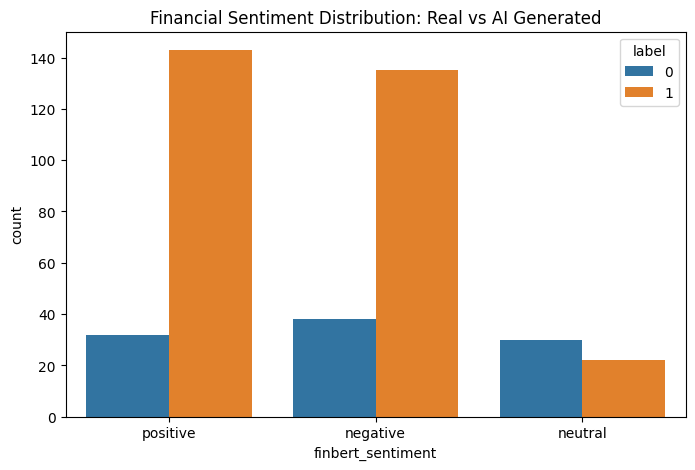

In [ ]:
# Sentiment
plt.figure(figsize=(8,5))

sns.countplot(
    data=feature_df,
    x="finbert_sentiment",
    hue="label"
)

plt.title(
    "Financial Sentiment Distribution: Real vs AI Generated"
)

plt.show()

The sentiment distribution shows differences between real and AI-generated articles. AI-generated samples display stronger sentiment polarity, suggesting that emotional expression may provide useful signals for detection.

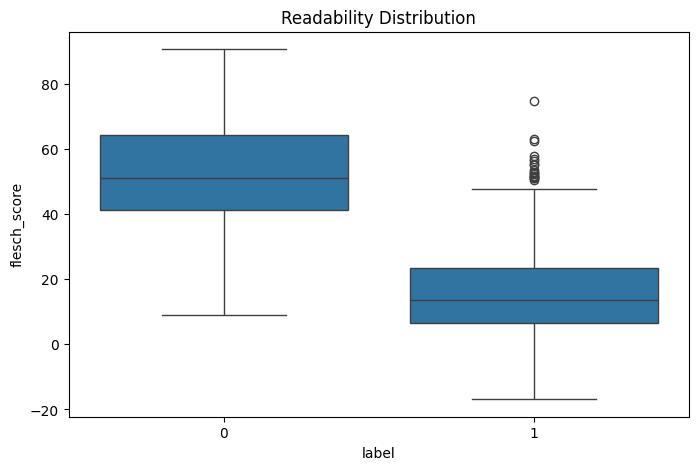

In [ ]:
# Readability
plt.figure(figsize=(8,5))

sns.boxplot(
    data=feature_df,
    x="label",
    y="flesch_score"
)

plt.title(
    "Readability Distribution"
)

plt.show()

AI-generated samples show different readability characteristics compared with real articles. This indicates that writing style features may contribute to classification performance.

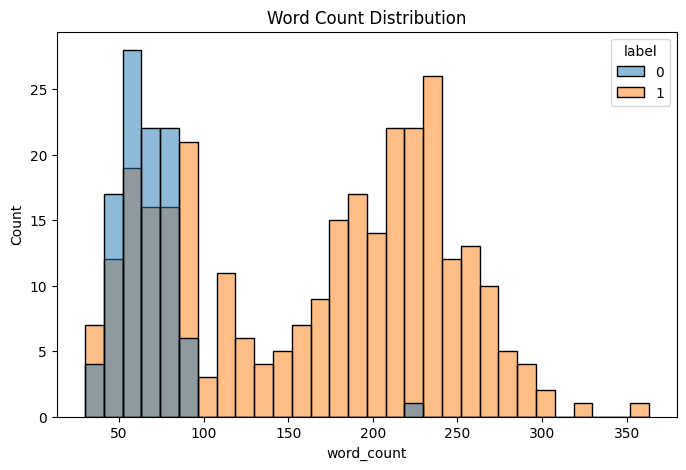

In [ ]:
# Word Count
plt.figure(figsize=(8,5))

sns.histplot(
    data=feature_df,
    x="word_count",
    hue="label",
    bins=30
)

plt.title(
    "Word Count Distribution"
)

plt.show()

AI-generated articles show different length distributions compared with real articles. Text length may therefore provide an additional linguistic feature for detection models.

---
## Section 5 — Synthesis & Communication


> ### What Generative AI Analysis Revealed?

The generative AI component was used to simulate realistic AI-generated
financial misinformation from authentic financial news articles.

A Large Language Model (GPT-4.1-mini) generated three controlled misinformation
styles:

| Type | Purpose |
|------|---------|
| Bullish | Simulates exaggerated positive misinformation |
| Bearish | Simulates exaggerated negative misinformation |
| Neutral | Simulates AI-written but fact-preserving text |

The final synthetic dataset combined authentic financial news with generated
AI-based content, creating examples of both real and AI-generated financial
articles for downstream analysis. These generated samples expanded the dataset and represented different
misinformation scenarios.

The results showed that AI-generated financial content can closely resemble
human-written financial news, especially when the content is rewritten without
obvious false claims.

---

> ### What Supervised Learning Revealed?

Supervised models were trained using extracted textual features including
sentiment, readability, linguistic patterns, and financial language features.

Baseline models achieved strong results, with Logistic Regression, Random Forest,
and SVM reaching F1-scores of 0.882, 0.873, and 0.889 respectively.

Hyperparameter tuning improved Random Forest performance to an F1-score of
0.912 and ROC-AUC of 0.938, while tuned SVM showed similar performance.
The Neural Network achieved comparable results but did not outperform classical
models.

FinBERT achieved the best overall performance with an accuracy of 0.950,
F1-score of 0.967, and ROC-AUC of 0.981, showing that financial-domain
transformer representations capture deeper semantic patterns.

Robustness evaluation showed strong detection of bullish and bearish generated
misinformation but lower performance on neutral AI rewrites. Error analysis
confirmed that false negatives mainly occurred in neutral rewrites, highlighting
the challenge of detecting AI-generated content that closely resembles authentic
financial news.

---

> ### What Causal Analysis Revealed?

The causal analysis investigated whether financial news sentiment was associated
with subsequent stock market returns. A backdoor adjustment approach was used
with company information as an observed confounder.

The estimated Average Treatment Effect (ATE) was -0.000265, indicating a very
small negative association between financial news sentiment and future returns.
This suggests that sentiment-related signals alone have limited direct impact on
short-term market movement.

The refutation test using a random common cause produced a similar estimate
(-0.000263) with a p-value of 0.98, indicating that the estimated effect was
stable under the added confounder.

Overall, the analysis suggests that while financial news sentiment may contain
market-relevant information, its isolated causal effect is economically small
and market behaviour is influenced by multiple external factors.

---

> ### How the Methodological Blocks Are Connected?

The three methodological components were combined into an end-to-end framework
for analysing AI-generated financial misinformation.

The generative AI block created realistic synthetic financial misinformation
from authentic news articles, allowing the detection models to evaluate
different manipulation scenarios.

The feature engineering and supervised learning blocks transformed financial
text into measurable linguistic, sentiment, and semantic representations to
identify AI-generated content. The detected misinformation-related signals were
then linked with real financial market data in the causal analysis block to
investigate whether such signals were associated with market movements.

Together, these blocks demonstrate both the detection capability of AI-generated
financial misinformation and its potential relationship with financial market
behaviour.

---

> ### Limitations & honest discussion

This analysis has certain limitations.

- The synthetic misinformation dataset was generated using controlled LLM prompts,
which may not fully represent naturally occurring misinformation in real
financial environments.

- The supervised models were evaluated on available datasets, so performance may
vary when exposed to new companies, market conditions, or unseen manipulation
strategies.

- The causal analysis estimates associations after controlling only for observed
variables. Other market factors such as macroeconomic events, investor behaviour,
and external news sources may influence returns and cannot be fully captured.

Therefore, the results should be interpreted as evidence of model capability
and potential relationships rather than proof of complete misinformation impact
on financial markets.

---

> ### Conclusion

This study shows that advanced NLP models can reliably detect AI-generated
financial misinformation, with FinBERT achieving the strongest detection
performance.

The analysis also suggests that misinformation-related textual signals have only
a small measurable effect on short-term market returns. While AI-generated
financial content can be detected effectively, its direct market impact depends
on broader financial and external factors.

---
## References

Araci, D. (2019). FinBERT: Financial Sentiment Analysis with BERT.
*University of Helsinki Digital Repository.*

Kaliyar, R. K., Goswami, A., & Narang, P. (2020). FakeBERT: Fake News Detection in Social Media Using BERT.
*IEEE Access, 8*, 154965–154976.

Zhou, J., et al. (2024). Synthetic Lies: Investigating LLM-generated misinformation pipelines.
*arXiv preprint.*

Guo, B., Zhang, X., Wang, Z., et al. (2023). How Close is ChatGPT to Human Experts? Comparison Corpus, Evaluation, and Detection.
*arXiv preprint.*

Pearl, J. (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.). Cambridge University Press.

Sharma, A., & Kiciman, E. (2020). DoWhy: An End-to-End Library for Causal Inference.
*arXiv:2011.04216.*

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., et al. (2011). Scikit-learn: Machine Learning in Python.
*Journal of Machine Learning Research, 12*, 2825–2830.

Dataset: Reuters Financial News Articles. Retrieved from https://www.reuters.com/markets/. Accessed June 28, 2026.

Dataset: Yahoo Finance Historical Market Data (accessed through yfinance). Retrieved from https://finance.yahoo.com/. Accessed June 25, 2026.

Dataset: Synthetic Financial Misinformation Dataset. Generated internally using GPT-4.1-mini. Accessed June 25, 2026.